# 02 — LFMC 数据读取与清洗（不做时空匹配）

本 notebook 仅完成 LFMC 点位数据的 **读取 + 标准化 + QC 标记 +（可选）站点-日聚合 + 导出**。

**不包含：**
- 与 VOD 的时空匹配
- 栅格化/像元化
- 机器学习建模或反演

---

## 产物

输出到 `configs/lfmc.yaml` 指定的 `out_dir`：
1. `lfmc_std.parquet`：标准化 + QC flags（尽量不删软异常）
2. `lfmc_site_day.parquet`：站点-日聚合（严格视图后聚合）
3. `lfmc_qc_report.json`：QC 统计报告与摘要


In [1]:
import os, sys
from pathlib import Path
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 让 notebook 能 import function/ 下的模块（兼容 VSCode Jupyter 的 cwd 行为）
cwd = Path.cwd().resolve()
if (cwd / "configs" / "lfmc.yaml").exists() and (cwd / "function").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "configs" / "lfmc.yaml").exists() and (cwd.parent / "function").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("找不到项目根目录：未发现 configs/lfmc.yaml 与 function/")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


import importlib
import function.lfmc.lfmc_clean as lfmc_clean
import function.lfmc.lfmc_qc as lfmc_qc
import function.lfmc.lfmc_io as lfmc_io
import function.lfmc.lfmc_export as lfmc_export
import function.lfmc.lfmc_dedup as lfmc_dedup

importlib.reload(lfmc_clean)
importlib.reload(lfmc_qc)
importlib.reload(lfmc_io)
importlib.reload(lfmc_export)
importlib.reload(lfmc_dedup)

from function.lfmc.lfmc_io import read_lfmc_raw
from function.lfmc.lfmc_clean import standardize_columns
from function.lfmc.lfmc_qc import add_qc_flags, make_strict_view
from function.lfmc.lfmc_export import export_parquet, export_report, summarize

# 如果你创建了 function/lfmc/lfmc_dedup.py
from function.lfmc.lfmc_dedup import deduplicate_site_day


## 1) 读取配置（configs/lfmc.yaml）

这里读取：
- 原始 xlsx 路径与 sheet 名称
- 字段映射（columns）
- QC 基础阈值（lfmc_min/max）
- 去重聚合策略（dedup_strategy）
- 输出目录与文件名


In [2]:
cfg_path = PROJECT_ROOT / "configs" / "lfmc.yaml"
cfg_all = yaml.safe_load(open(cfg_path, "r", encoding="utf-8"))
cfg = cfg_all["lfmc"]

cfg


{'raw_path': 'G:/data/Globe LFMC/Globe-LFMC-2.0 final.xlsx',
 'sheet_name': 'LFMC data',
 'out_dir': 'G:/data/Globe LFMC/processed',
 'out_std_name': 'lfmc_std.parquet',
 'out_dedup_name': 'lfmc_site_day.parquet',
 'out_report_name': 'lfmc_qc_report.json',
 'out_grid_day_name': 'lfmc_grid_day_0p1.parquet',
 'normalize_to_date': True,
 'dedup_strategy': 'median',
 'columns': {'sorting_id': 'Sorting ID',
  'site_name': 'Site Name',
  'lat': 'Latitude',
  'lon': 'Longitude',
  'date': 'Sampling Date (YYYYMMDD)',
  'time': 'Sampling Time (hh:mm)',
  'lfmc': 'LFMC (%)',
  'extra_info_flag': 'Extra Info Flag',
  'isolated_iforest': 'Isolated data point',
  'species': 'Species collected',
  'functional_type': 'Species functional type',
  'individual_or_mean': 'Individual or mean',
  'protocol': 'Protocol',
  'source': 'Database'},
 'lfmc_min': 0,
 'lfmc_max': 400,
 'suspect_keywords': ['outlier',
  'anomal',
  'error',
  'suspect',
  'dead',
  'flower',
  'bud',
  'wrong',
  'invalid']}

## 2) 读取原始 LFMC 表（LFMC Data sheet）

输出：
- `df_raw`：原始 DataFrame（未做任何清洗）
检查点：
- 行数/列数是否合理
- 关键列是否存在（比如 lat/lon/date/lfmc）


In [3]:
df_raw = read_lfmc_raw(cfg)

print("df_raw shape:", df_raw.shape)
print("first 20 columns:", list(df_raw.columns[:20]))
df_raw.head(3)


df_raw shape: (293796, 38)
first 20 columns: ['Sorting ID', 'Contact', 'Site name', 'Country', 'State/Region', 'Latitude (WGS84, EPSG:4326)', 'Longitude (WGS84, EPSG:4326)', 'Sampling date (YYYYMMDD)', 'Sampling time (24h format)', 'Protocol', 'LFMC value (%)', 'Species collected', 'Species functional type', 'Individual sample or mean value', 'Old or new leaves', 'Elevation (m.a.s.l)', 'Slope (%)', 'Extra information/Quality Flag', 'Isolated data point', 'Reference']


,Sorting ID,Contact,Site name,Country,State/Region,"Latitude (WGS84, EPSG:4326)","Longitude (WGS84, EPSG:4326)",Sampling date (YYYYMMDD),Sampling time (24h format),Protocol,...,Precipitation sum 12 weeks before (mm/day),2m Relative Humidity at 06h (%),2m Relative Humidity at 09h (%),2m Relative Humidity at 12h (%),2m Relative Humidity at 15h (%),2m Air Temperature 24h max (K),2m Air Temperature 24h mean (K),Vapour Pressure 24h mean (hPa),10m Wind Speed 24h mean (m/s),2m Dewpoint Temperature 24h mean (K)
0,1,Beget,ArgBA1,Argentina,Buenos Aires,-35.267417,-57.614278,2009-04-06,12:05:00,16,...,326.990002,73.560074,75.661018,58.473328,55.678799,297.209686,291.944214,15.791007,3.237640,286.945831
1,2,Beget,ArgBA1,Argentina,Buenos Aires,-35.267417,-57.614278,2009-12-17,12:48:00,16,...,255.830002,90.797096,69.246300,52.833767,49.400108,298.885498,294.555634,17.334539,5.512757,288.346405
2,3,Beget,ArgBA1,Argentina,Buenos Aires,-35.267417,-57.614278,2009-12-17,12:48:00,16,...,255.830002,90.797096,69.246300,52.833767,49.400108,298.885498,294.555634,17.334539,5.512757,288.346405


## 3) 标准化字段（统一列名、类型、日期解析）

`standardize_columns()` 会做：
- 根据 `cfg.columns` 重命名关键列
- 转换 `lat/lon/lfmc` 为数值
- 解析采样日期/时间为 `sampling_datetime`，并生成 `date`（日尺度）
- 生成稳定的 `site_id`
- 生成辅助列：`year`, `doy`

输出：
- `df_std`：标准化后的 DataFrame（尚未做 QC 筛选）


In [4]:
df_std = standardize_columns(df_raw, cfg)

# 核心列：只检查标准化后（被函数改名/生成）的列
core_cols = ["sorting_id", "site_name", "lat", "lon", "date", "lfmc_pct"]
present = [c for c in core_cols if c in df_std.columns]

print("df_std shape:", df_std.shape)
print("core columns present:", present)

df_std[present].head(5)


df_std shape: (293796, 43)
core columns present: ['sorting_id', 'site_name', 'lat', 'lon', 'date', 'lfmc_pct']


,sorting_id,site_name,lat,lon,date,lfmc_pct
0,1,ArgBA1,-35.267417,-57.614278,2009-04-06,210.085306
1,2,ArgBA1,-35.267417,-57.614278,2009-12-17,167.272112
2,3,ArgBA1,-35.267417,-57.614278,2009-12-17,377.164808
3,4,ArgBA1,-35.267417,-57.614278,2010-03-08,94.099472
4,5,ArgBA1,-35.267417,-57.614278,2010-03-08,340.685939


## 4) 标准化质量检查（快速 sanity check）

目标：确认 date/坐标/LFMC 的解析没有明显问题。

检查点：
- date 是否为 datetime 类型、是否存在大量 NaT
- lat/lon 是否落在合理范围
- lfmc_pct 是否数值、是否出现明显异常（比如全部 NaN）


In [5]:
print("date dtype:", df_std["date"].dtype if "date" in df_std.columns else None)
print("missing date ratio:", float(df_std["date"].isna().mean()) if "date" in df_std.columns else None)

if "lat" in df_std.columns and "lon" in df_std.columns:
    print("lat range:", float(np.nanmin(df_std["lat"])), float(np.nanmax(df_std["lat"])))
    print("lon range:", float(np.nanmin(df_std["lon"])), float(np.nanmax(df_std["lon"])))

print("lfmc missing ratio:", float(df_std["lfmc_pct"].isna().mean()))
df_std["lfmc_pct"].describe()

date dtype: datetime64[ns]
missing date ratio: 0.0
lat range: -42.848333333333336 65.11638889
lon range: -155.5469444 150.9244144
lfmc missing ratio: 0.0


count    293796.000000
mean        110.243562
std        1155.984285
min           0.000000
25%          78.677723
50%          97.583422
75%         121.000000
max      599999.000000
Name: lfmc_pct, dtype: float64

## 5) 添加 QC flags（不删除软异常）

我们按“可追溯”原则：
- 硬错误：`qc_hard=1`（如缺日期/坐标越界/LFMC 越界），可用于严格过滤
- 软异常：`provider_suspect`（来自 extra_info_flag 关键词）、`isolated_iforest`（论文的离群标记）等

输出：
- `df_std_qc`：标准化 + QC flags
- `report`：QC 计数报告（dict）


In [6]:
df_std_qc, report = add_qc_flags(df_std, cfg)

print("QC report:")
for k, v in report.items():
    print(f"  {k}: {v}")

qc_cols = ["qc_hard", "bad_date", "bad_coord", "bad_lfmc", "provider_suspect", "isolated_iforest",
           "site_coord_conflict", "coord_site_conflict"]
qc_cols = [c for c in qc_cols if c in df_std_qc.columns]

df_std_qc[qc_cols].head(5)


QC report:
  n_rows: 293796
  n_qc_hard: 870
  n_bad_date: 0
  n_bad_coord: 0
  n_bad_lfmc: 870
  n_provider_suspect: 867
  n_isolated_iforest: 6245
  n_site_coord_conflict: 0
  n_coord_site_conflict: 971
  n_dead_protocol: 35694


,qc_hard,bad_date,bad_coord,bad_lfmc,provider_suspect,isolated_iforest,site_coord_conflict,coord_site_conflict
0,0,0,0,0,0,False,0,0
1,0,0,0,0,0,False,0,0
2,0,0,0,0,0,False,0,0
3,0,0,0,0,0,False,0,0
4,0,0,0,0,0,True,0,0


## 6) 生成严格视图（Strict view）

默认策略（你已确认）：
- 仅剔除 `qc_hard==1` 的记录
- **不**剔除 `isolated_iforest`（离群标记）
- **不**剔除 `provider_suspect`（文本弱提示）

输出：
- `df_strict_live`


In [7]:
df_strict_live = make_strict_view(
    df_std_qc,
    drop_isolated_iforest=False,
    drop_provider_suspect=False,
    drop_dead_protocol=True,    # 剔除 dead_protocol==1
)

print("df_strict_live shape:", df_strict_live.shape)
print("strict_live summary:", summarize(df_strict_live))


df_strict_live shape: (257484, 51)
strict_live summary: {'n_rows': 257484, 'lfmc_min': 0.0, 'lfmc_max': 400.0, 'lfmc_mean': 108.19336367179464, 'date_min': '1977-04-14 00:00:00', 'date_max': '2023-01-30 00:00:00', 'n_sites': 2158}


## 7.1) 对QC过滤（去除了qc_hard == 1、dead_protocol == 1）之后的结果，使用站点-日-采样植被类型 聚合（site_id + date）

目的：
- 同一站点(不是siteID相同，而是经纬度，其实也可以用siteID，因为这套数据应该是能够保证对应的，但是更严谨一些还是经纬度)，其同一天可能有多次采样或多条记录
- 我们输出一个“站点-日-采样植被”版本，方便后续与日尺度遥感数据耦合（但本阶段不做匹配）
- 保留Yebra等人所填写的IGBP MainType内容（500m分辨率），方便后续实验。

策略由 `cfg.dedup_strategy` 控制：
- median / mean / last

这样我们获得了站点-日-植被类型的结果，后续用站点自带的IGBP来选取冠层高度的类型。

In [ ]:
strategy = cfg.get("dedup_strategy", "median")

df_site_day = deduplicate_site_day(
    df_strict_live,
    strategy=strategy,
    group_by_vegtype=True,
    group_by_location=True,        # 用经纬度替代聚合键
    location_precision_deg=1e-4,
    location_id_col="site_loc_id",
    keep_igbp=True,
    igbp_col="IGBP Land Cover",
)

print("df_site_day shape:", df_site_day.shape)
print("df_site_day columns:", df_site_day.columns.tolist())
df_site_day.head(5) # site_loc_id是经纬度量化位置 ID

df_site_day shape: (147670, 16)
df_site_day columns: ['site_loc_id', 'date', 'veg_type', 'lfmc_pct', 'lat', 'lon', 'n_obs', 'site_name', 'source', 'protocol', 'species', 'igbp_500m', 'igbp_500m_nunique', 'site_id', 'site_id_nunique', 'veg_type_unknown_flag']


,site_loc_id,date,veg_type,lfmc_pct,lat,lon,n_obs,site_name,source,protocol,species,igbp_500m,igbp_500m_nunique,site_id,site_id_nunique,veg_type_unknown_flag
0,-155866_1282338,2006-04-11,Grass,100.00,-15.58656,128.2338,1,Parry Lagoons,"Newnham, G.J., Verbesselt, J., Grant, I.F., An...",18,"Aristida sp., Sorghum stipoideum",Grasslands,1,1561b4dc54d2,1,0
1,-155866_1282338,2006-04-26,Grass,70.00,-15.58656,128.2338,1,Parry Lagoons,"Newnham, G.J., Verbesselt, J., Grant, I.F., An...",18,"Aristida sp., Sorghum stipoideum",Grasslands,1,1561b4dc54d2,1,0
2,-155866_1282338,2006-05-09,Grass,108.00,-15.58656,128.2338,1,Parry Lagoons,"Newnham, G.J., Verbesselt, J., Grant, I.F., An...",18,"Aristida sp., Sorghum stipoideum, Whiteochloa sp.",Grasslands,1,1561b4dc54d2,1,0
3,-155866_1282338,2006-05-23,Grass,90.00,-15.58656,128.2338,1,Parry Lagoons,"Newnham, G.J., Verbesselt, J., Grant, I.F., An...",18,"Aristida sp., Sorghum stipoideum, Whiteochloa sp.",Grasslands,1,1561b4dc54d2,1,0
4,-155866_1282338,2006-06-12,Grass,87.31,-15.58656,128.2338,1,Parry Lagoons,"Newnham, G.J., Verbesselt, J., Grant, I.F., An...",18,"Aristida sp., Sorghum stipoideum, Eriachne obtusa",Grasslands,1,1561b4dc54d2,1,0


## 7.2)  在7.1）的基础上，聚合至0.1°像元的结果（最终得到逐日的0.1°各植被类型的结果）。


In [ ]:
import numpy as np
import pandas as pd


# -----------------------------
# 0.1° grid mapping helpers
# grid centers:
#   lat:  89.95, 89.85, ..., -89.95  (step -0.1)
#   lon: -179.95, -179.85, ..., 179.95 (step +0.1)
# -----------------------------

def to_grid_center_lat(lat: pd.Series) -> pd.Series:
    """
    Map latitude to nearest 0.1° grid center aligned to 89.95..-89.95.
    Formula (center index k):
      center = 89.95 - 0.1*k
      k = round((89.95 - lat)/0.1)
    """
    lat_num = pd.to_numeric(lat, errors="coerce")
    k = np.rint((89.95 - lat_num) / 0.1)
    center = 89.95 - 0.1 * k

    # clamp to valid bounds
    center = np.clip(center, -89.95, 89.95)

    # avoid -0.0
    center = np.where(np.isclose(center, 0.0), 0.0, center)
    return pd.Series(center, index=lat.index)


def to_grid_center_lon(lon: pd.Series) -> pd.Series:
    """
    Map longitude to nearest 0.1° grid center aligned to -179.95..179.95.
    Steps:
      1) wrap lon into [-180, 180)
      2) center = -179.95 + 0.1*j
         j = round((lon_wrapped - (-179.95))/0.1) = round((lon_wrapped + 179.95)/0.1)
    """
    lon_num = pd.to_numeric(lon, errors="coerce")

    # wrap to [-180, 180)
    lon_wrapped = ((lon_num + 180) % 360) - 180

    j = np.rint((lon_wrapped + 179.95) / 0.1)
    center = -179.95 + 0.1 * j

    # clamp
    center = np.clip(center, -179.95, 179.95)

    # fix -0.0
    center = np.where(np.isclose(center, 0.0), 0.0, center)
    return pd.Series(center, index=lon.index)


# -----------------------------
# 7.2) site-day-(veg_type) -> 0.1° grid-day-(veg_type)
# -----------------------------

def aggregate_to_grid_day(
    df_site_day: pd.DataFrame,
    strategy: str = "mean",
    keep_cols: list[str] | None = None,
    require_veg_type: bool = True,
) -> pd.DataFrame:
    """
    Aggregate site-day-(veg_type) records to 0.1° grid-day-(veg_type).

    Output group key (fixed):
      (date, grid_lat, grid_lon, veg_type)

    strategy: 'median' | 'mean' | 'last'
    keep_cols: extra columns to keep by 'first' (optional)
    require_veg_type: if True, veg_type must exist; otherwise fill 'All'

    Expected input columns:
      - date, lat, lon, lfmc_pct
      - veg_type (recommended/required)
      - site_id (for n_sites)
      - n_obs (optional; if present, will be summed)
    """
    df = df_site_day.copy()

    # --- ensure veg_type exists ---
    if "veg_type" not in df.columns:
        if require_veg_type:
            raise ValueError(
                "veg_type not found in df_site_day. "
                "Run step 7 with group_by_vegtype=True (or provide veg_col) first."
            )
        else:
            df["veg_type"] = "All"

    # --- drop invalid rows to avoid NaT / NaN coordinates / NaN lfmc ---
    needed = ["date", "lat", "lon", "lfmc_pct", "veg_type"]
    df = df.dropna(subset=[c for c in needed if c in df.columns])

    # 1) grid mapping
    df["grid_lat"] = to_grid_center_lat(df["lat"])
    df["grid_lon"] = to_grid_center_lon(df["lon"])

    # 2) choose reducer
    strategy = (strategy or "mean").lower()
    if strategy not in {"median", "mean", "last"}:
        raise ValueError("strategy must be one of: median / mean / last")

    agg_lfmc = {"median": "median", "mean": "mean", "last": "last"}[strategy]

    # 3) group (always include veg_type)
    gcols = ["date", "grid_lat", "grid_lon", "veg_type"]

    agg_dict = {
        "lfmc_pct": agg_lfmc,

        # how many unique sites contribute to this grid-day-veg_type
        "site_id": "nunique" if "site_id" in df.columns else "size",

        # number of raw obs (already aggregated at site-day level)
        "n_obs": "sum" if "n_obs" in df.columns else "size",
    }

    # optional columns keep first
    if keep_cols:
        for c in keep_cols:
            if c in df.columns and c not in agg_dict:
                agg_dict[c] = "first"

    out = (
        df.groupby(gcols, dropna=False, as_index=False)
          .agg(agg_dict)
          .rename(columns={
              "site_id": "n_sites",
              "n_obs": "n_obs_sum"
          })
    )

    # 4) n_records = number of site-day records merged into each grid-day-veg_type
    n_records = (
        df.groupby(gcols, dropna=False)
          .size()
          .reset_index(name="n_records")
    )
    out = out.merge(n_records, on=gcols, how="left")

    return out

# ---- A) Scheme A: keep point LFMC, only map to 0.1° grid ----
df_A_site_day_match = df_site_day.copy()
df_A_site_day_match["grid_lat"] = to_grid_center_lat(df_A_site_day_match["lat"])
df_A_site_day_match["grid_lon"] = to_grid_center_lon(df_A_site_day_match["lon"])

gcols_A = ["date", "grid_lat", "grid_lon"] + (["veg_type"] if "veg_type" in df_A_site_day_match.columns else [])
df_A_site_day_match["n_site_samples_in_pixel_day"] = (
    df_A_site_day_match.groupby(gcols_A, dropna=False)["lfmc_pct"].transform("size")
)

print("Scheme A df_A_site_day_match shape:", df_A_site_day_match.shape)
display(df_A_site_day_match.head(5))

# ---- B) Scheme B: aggregate point LFMC to 0.1° grid-day-veg_type ----
grid_strategy = cfg.get("grid_dedup_strategy", cfg.get("dedup_strategy", "median"))
df_B_grid_day = aggregate_to_grid_day(
    df_site_day,
    strategy=grid_strategy,
    keep_cols=["source"] if "source" in df_site_day.columns else None,
    require_veg_type=True
)

print("Scheme B df_B_grid_day shape:", df_B_grid_day.shape)
display(df_B_grid_day.head(5))


Scheme A df_A_site_day_match shape: (147670, 19)


,site_loc_id,date,veg_type,lfmc_pct,lat,lon,n_obs,site_name,source,protocol,species,igbp_500m,igbp_500m_nunique,site_id,site_id_nunique,veg_type_unknown_flag,grid_lat,grid_lon,n_site_samples_in_pixel_day
0,-155866_1282338,2006-04-11,Grass,100.00,-15.58656,128.2338,1,Parry Lagoons,"Newnham, G.J., Verbesselt, J., Grant, I.F., An...",18,"Aristida sp., Sorghum stipoideum",Grasslands,1,1561b4dc54d2,1,0,-15.55,128.25,1
1,-155866_1282338,2006-04-26,Grass,70.00,-15.58656,128.2338,1,Parry Lagoons,"Newnham, G.J., Verbesselt, J., Grant, I.F., An...",18,"Aristida sp., Sorghum stipoideum",Grasslands,1,1561b4dc54d2,1,0,-15.55,128.25,1
2,-155866_1282338,2006-05-09,Grass,108.00,-15.58656,128.2338,1,Parry Lagoons,"Newnham, G.J., Verbesselt, J., Grant, I.F., An...",18,"Aristida sp., Sorghum stipoideum, Whiteochloa sp.",Grasslands,1,1561b4dc54d2,1,0,-15.55,128.25,1
3,-155866_1282338,2006-05-23,Grass,90.00,-15.58656,128.2338,1,Parry Lagoons,"Newnham, G.J., Verbesselt, J., Grant, I.F., An...",18,"Aristida sp., Sorghum stipoideum, Whiteochloa sp.",Grasslands,1,1561b4dc54d2,1,0,-15.55,128.25,1
4,-155866_1282338,2006-06-12,Grass,87.31,-15.58656,128.2338,1,Parry Lagoons,"Newnham, G.J., Verbesselt, J., Grant, I.F., An...",18,"Aristida sp., Sorghum stipoideum, Eriachne obtusa",Grasslands,1,1561b4dc54d2,1,0,-15.55,128.25,1


Scheme B df_B_grid_day shape: (140112, 9)


,date,grid_lat,grid_lon,veg_type,lfmc_pct,n_sites,n_obs_sum,source,n_records
0,1977-04-14,37.25,-122.15,Shrub,176.0,1,1,US National Fuel Moisture Database https://www...,1
1,1977-04-14,37.45,-122.35,Shrub,203.0,1,1,US National Fuel Moisture Database https://www...,1
2,1977-04-15,37.05,-121.85,Shrub,96.0,1,1,US National Fuel Moisture Database https://www...,1
3,1977-05-03,37.05,-121.85,Shrub,177.0,1,1,US National Fuel Moisture Database https://www...,1
4,1977-05-05,37.45,-122.35,Shrub,166.0,1,1,US National Fuel Moisture Database https://www...,1


## 8) 导出产物（parquet + json report）

本节将把 LFMC 处理流程的关键产物写入磁盘，便于后续步骤（特征抽取 / 时空匹配 / 建模 / 可视化）直接读取，无需反复读取 Excel。

导出文件（保存到 `configs/lfmc.yaml` 指定的 `out_dir`）：

- **`lfmc_std.parquet`**：`df_std_qc`  
  标准化后的逐条样本表（逐条采样记录），包含：
  - 统一后的核心字段（`site_id/site_name/lat/lon/date/lfmc_pct/...`）
  - QC 标识（`qc_hard/bad_* / provider_suspect / isolated_iforest / dead_protocol / ...`）
  - 以及原始表格的大部分字段（未删除，便于追溯）

- **`lfmc_strict_live.parquet`**：`df_strict_live`  
  通过 QC 严格筛选后的逐条样本表（strict view），作为后续聚合（第 7 步）的输入。

- **`lfmc_site_day.parquet`**：`df_site_day`  
  站点-日-植被类型聚合后的表（方案 A/B 的共同中间产物）。  
  注意：如果在第 7 步启用了 `group_by_location=True`，则会额外包含 `site_loc_id`（经纬度量化 ID）和 `site_id`（代表/回溯用）。

- **`lfmc_site_day_A_point_with_grid0p1.parquet`**：`df_A_site_day_match`（方案 A）  
  **不对 LFMC 做空间聚合**，保留站点点尺度标签，仅新增：
  - `grid_lat/grid_lon`：站点落入的 0.1° 网格中心
  - `n_site_samples_in_pixel_day`：同像元-日-veg_type 的站点样本数（诊断用）  
  用于后续按 0.1° 像元抽取 VOD/树高等特征，实现“点标签 + 像元特征”。

- **`lfmc_grid_day_B_0p1deg.parquet`**：`df_B_grid_day`（方案 B，可选）  
  将 `df_site_day` 进一步聚合到 **0.1° 网格-日-植被类型**尺度（同一天同网格同 veg_type 合并），
  得到像元尺度的逐日 LFMC 标签（用于“像元标签 + 像元特征”的训练方案）。

- **`lfmc_qc_report.json`**：QC 统计报告 + 数据摘要信息  
  包含：
  - `qc_report`、`std_summary`、`strict_summary`、`site_day_summary`
  - 以及（如有）`schemeA_summary / schemeA_path`、`schemeB_summary / schemeB_path`

> 建议：下游流程统一从 parquet 读取，避免反复读取 xlsx（慢且易出现解析差异）。


In [14]:
from pathlib import Path

out_dir = Path(cfg["out_dir"])
out_dir.mkdir(parents=True, exist_ok=True)

# 你原有的名字（保持兼容）
out_std = out_dir / cfg.get("out_std_name", "lfmc_std.parquet")
out_site_day = out_dir / cfg.get("out_dedup_name", "lfmc_site_day.parquet")
out_report = out_dir / cfg.get("out_report_name", "lfmc_qc_report.json")

# 新增：strict view（QC后逐条样本）
out_strict = out_dir / cfg.get("out_strict_name", "lfmc_strict_live.parquet")

# 新增：方案A（点尺度 + 0.1°匹配）
out_A = out_dir / cfg.get("out_schemeA_name", "lfmc_site_day_A_point_with_grid0p1.parquet")

# 新增：方案B（像元尺度 0.1°聚合）
out_B = out_dir / cfg.get("out_schemeB_name", "lfmc_grid_day_B_0p1deg.parquet")


# -------- export parquet --------
export_parquet(df_std_qc, str(out_std))
export_parquet(df_strict_live, str(out_strict))
export_parquet(df_site_day, str(out_site_day))

# Scheme A must exist if you ran 7.5 A-branch
if "df_A_site_day_match" in globals() and df_A_site_day_match is not None:
    export_parquet(df_A_site_day_match, str(out_A))
else:
    out_A = None

# Scheme B is optional (only if you computed df_B_grid_day)
if "df_B_grid_day" in globals() and df_B_grid_day is not None:
    export_parquet(df_B_grid_day, str(out_B))
else:
    out_B = None


# -------- report --------
report_all = {
    "qc_report": report,
    "std_summary": summarize(df_std_qc),
    "strict_summary": summarize(df_strict_live),
    "site_day_summary": summarize(df_site_day),
    "dedup_strategy": strategy,
}

# attach Scheme A info
if out_A is not None:
    report_all["schemeA_summary"] = summarize(df_A_site_day_match)
    report_all["schemeA_path"] = str(out_A)

# attach Scheme B info
if out_B is not None:
    report_all["schemeB_summary"] = summarize(df_B_grid_day)
    report_all["schemeB_path"] = str(out_B)

export_report(report_all, str(out_report))


# -------- prints --------
print("Saved std:", out_std)
print("Saved strict_live:", out_strict)
print("Saved site_day:", out_site_day)
if out_A is not None:
    print("Saved schemeA_point_with_grid0p1:", out_A)
if out_B is not None:
    print("Saved schemeB_grid_day_0p1deg:", out_B)
print("Saved report:", out_report)


Saved std: G:\data\Globe LFMC\processed\lfmc_std.parquet
Saved strict_live: G:\data\Globe LFMC\processed\lfmc_strict_live.parquet
Saved site_day: G:\data\Globe LFMC\processed\lfmc_site_day.parquet
Saved schemeA_point_with_grid0p1: G:\data\Globe LFMC\processed\lfmc_site_day_A_point_with_grid0p1.parquet
Saved schemeB_grid_day_0p1deg: G:\data\Globe LFMC\processed\lfmc_grid_day_B_0p1deg.parquet
Saved report: G:\data\Globe LFMC\processed\lfmc_qc_report.json


## 9) 基本分布可视化（建议保留）

目的：
- 检查 LFMC 分布是否合理
- 检查年份覆盖是否符合预期
- 检查每站点样本数量分布（是否存在异常站点）

这些图不改变数据，只用于核对。


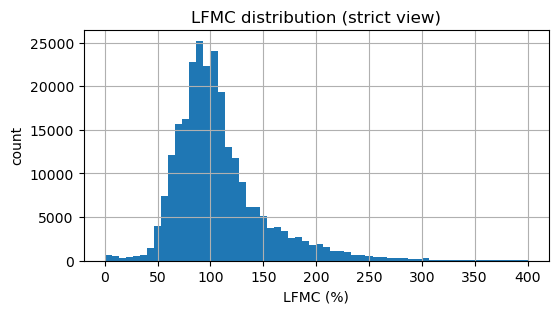

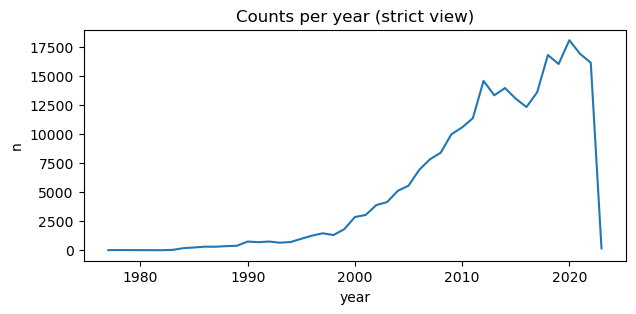

In [11]:
plt.figure(figsize=(6,3))
df_strict_live["lfmc_pct"].hist(bins=60)
plt.title("LFMC distribution (strict view)")
plt.xlabel("LFMC (%)")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(7,3))
df_strict_live.groupby("year")["lfmc_pct"].count().plot()
plt.title("Counts per year (strict view)")
plt.xlabel("year")
plt.ylabel("n")
plt.show()


### 9.1) LFMC 分布对比（strict vs site_day vs A vs B）

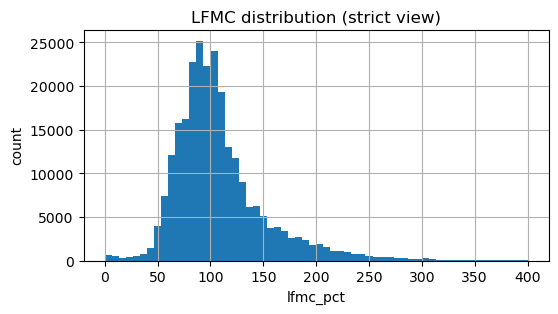

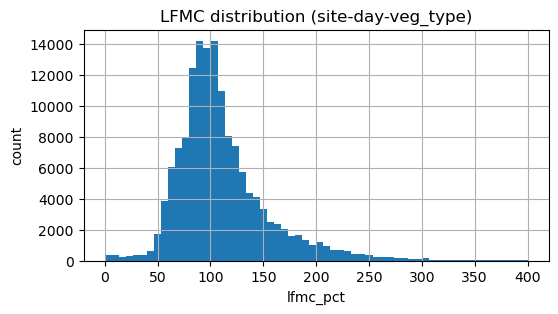

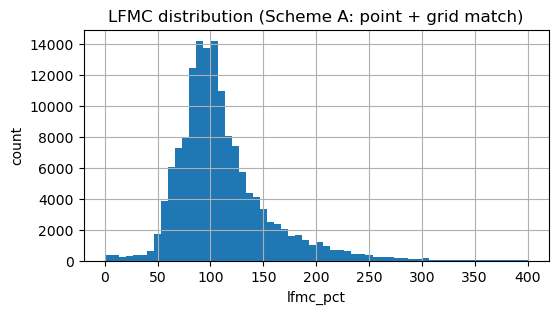

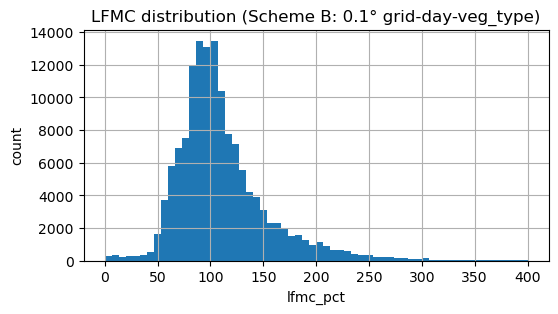

In [16]:
import matplotlib.pyplot as plt

def plot_hist(df, col, title, bins=60):
    plt.figure(figsize=(6,3))
    df[col].dropna().hist(bins=bins)
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

# strict
plot_hist(df_strict_live, "lfmc_pct", "LFMC distribution (strict view)")

# site_day（第7步输出）
if "df_site_day" in globals() and df_site_day is not None:
    plot_hist(df_site_day, "lfmc_pct", "LFMC distribution (site-day-veg_type)")

# Scheme A（点尺度+像元匹配，本质同site_day，但可以确认没丢数据）
if "df_A_site_day_match" in globals() and df_A_site_day_match is not None:
    plot_hist(df_A_site_day_match, "lfmc_pct", "LFMC distribution (Scheme A: point + grid match)")

# Scheme B（0.1°像元标签）
if "df_B_grid_day" in globals() and df_B_grid_day is not None:
    plot_hist(df_B_grid_day, "lfmc_pct", "LFMC distribution (Scheme B: 0.1° grid-day-veg_type)")


### 9.2) 年份覆盖对比（同样四个表）

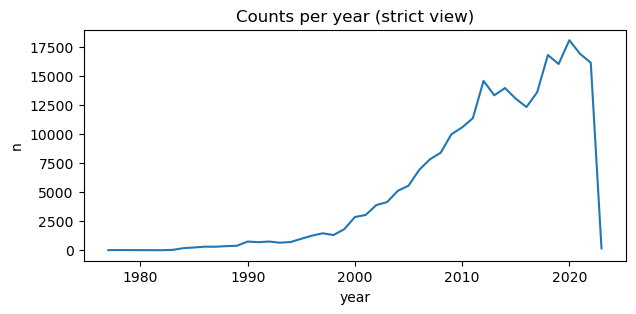

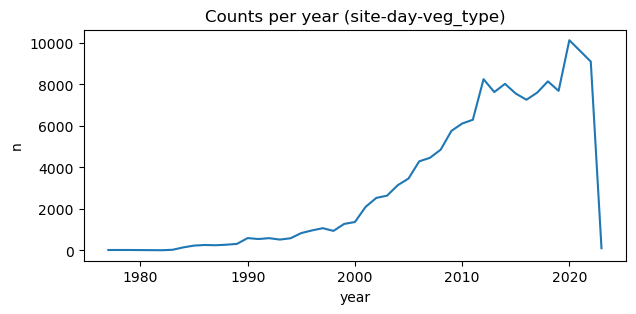

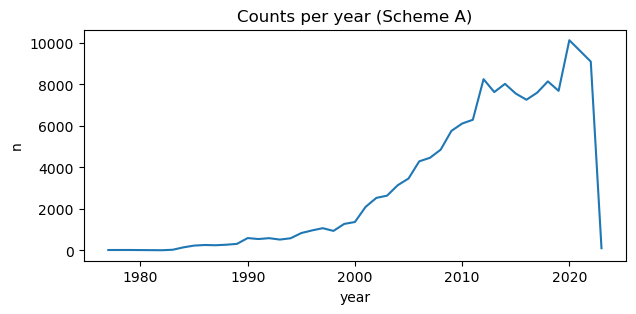

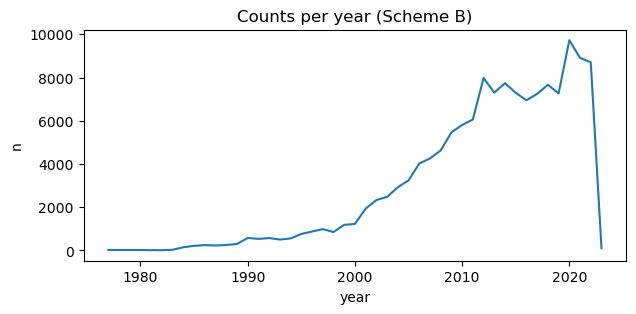

In [17]:
def plot_counts_per_year(df, title):
    if "year" in df.columns:
        s = df.groupby("year")["lfmc_pct"].count()
    else:
        # fallback: from date
        year = pd.to_datetime(df["date"]).dt.year
        s = df.assign(year=year).groupby("year")["lfmc_pct"].count()

    plt.figure(figsize=(7,3))
    s.plot()
    plt.title(title)
    plt.xlabel("year")
    plt.ylabel("n")
    plt.show()

plot_counts_per_year(df_strict_live, "Counts per year (strict view)")

if "df_site_day" in globals() and df_site_day is not None:
    plot_counts_per_year(df_site_day, "Counts per year (site-day-veg_type)")

if "df_A_site_day_match" in globals() and df_A_site_day_match is not None:
    plot_counts_per_year(df_A_site_day_match, "Counts per year (Scheme A)")

if "df_B_grid_day" in globals() and df_B_grid_day is not None:
    plot_counts_per_year(df_B_grid_day, "Counts per year (Scheme B)")


### 9.3) 各 veg_type 样本量检查

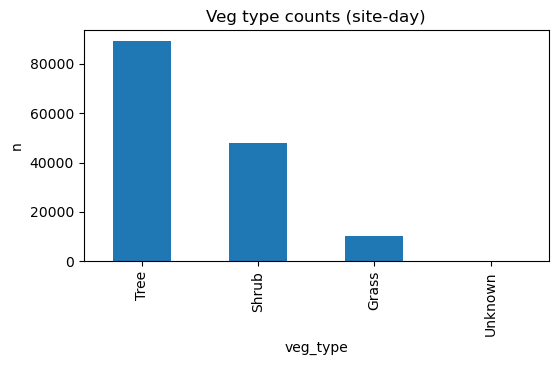

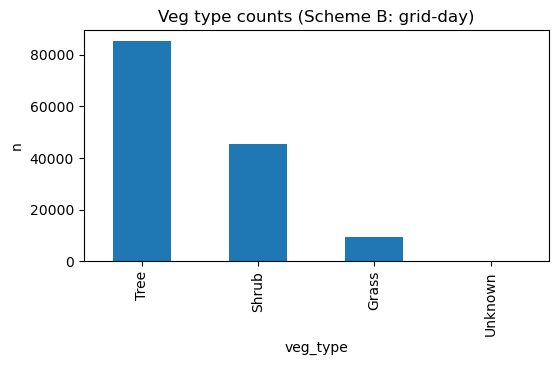

In [18]:
def plot_counts_by_veg(df, title):
    if "veg_type" not in df.columns:
        print(title, ": veg_type not found, skip.")
        return
    s = df["veg_type"].value_counts(dropna=False)
    plt.figure(figsize=(6,3))
    s.plot(kind="bar")
    plt.title(title)
    plt.xlabel("veg_type")
    plt.ylabel("n")
    plt.show()

if "df_site_day" in globals() and df_site_day is not None:
    plot_counts_by_veg(df_site_day, "Veg type counts (site-day)")

if "df_B_grid_day" in globals() and df_B_grid_day is not None:
    plot_counts_by_veg(df_B_grid_day, "Veg type counts (Scheme B: grid-day)")


## 10) 结果检查清单

运行成功后，你应该确认：

1. `df_raw` 行列数正常，且包含关键列。
2. `df_std_qc` / `df_strict_live` 中：
   - `date` 不应大量缺失；
   - `lat/lon` 范围合理；
   - `lfmc_pct` 不是全 NaN。
3. QC 统计合理：`qc_hard` 比例不应异常（通常不会非常高）。
4. 聚合后数据合理：
   - `df_site_day` 行数 <= `df_strict_live`；
   - `n_obs` 多为 1 或小整数；
   - 若启用 `group_by_location=True`，请检查 `site_loc_id` 的唯一数量与空间分布合理。
5. 输出文件数量正确（以本项目默认配置为例）：
   - `lfmc_std.parquet`
   - `lfmc_strict_live.parquet`
   - `lfmc_site_day.parquet`
   - `lfmc_site_day_A_point_with_grid0p1.parquet`（方案 A）
   - `lfmc_grid_day_B_0p1deg.parquet`（方案 B，可选）
   - `lfmc_qc_report.json`

若异常：
- 首先检查 `configs/lfmc.yaml` 的 columns 映射是否与实际列名一致。


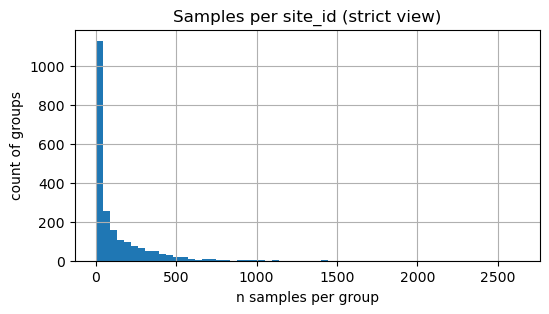

site_id groups: 2158
counts quantiles:
0.50     37.00
0.90    353.30
0.95    472.00
0.99    890.29
Name: lfmc_pct, dtype: float64
rows df_site_day: 147670
rows Scheme A: 147670
rows Scheme B grid-day: 140112
unique grid cells: 1385


In [19]:
import matplotlib.pyplot as plt

# choose grouping key
key = "site_loc_id" if "site_loc_id" in df_strict_live.columns else "site_id"

site_counts = df_strict_live.groupby(key)["lfmc_pct"].count()

plt.figure(figsize=(6,3))
site_counts.hist(bins=60)
plt.title(f"Samples per {key} (strict view)")
plt.xlabel("n samples per group")
plt.ylabel("count of groups")
plt.show()

print(f"{key} groups:", site_counts.size)
print("counts quantiles:")
print(site_counts.quantile([0.5, 0.9, 0.95, 0.99]))

# Scheme A: still point-scale, should have same number of rows as df_site_day
if "df_A_site_day_match" in globals() and df_A_site_day_match is not None:
    print("rows df_site_day:", len(df_site_day))
    print("rows Scheme A:", len(df_A_site_day_match))

# Scheme B: grid scale, should be smaller than df_site_day typically
if "df_B_grid_day" in globals() and df_B_grid_day is not None:
    print("rows Scheme B grid-day:", len(df_B_grid_day))
    print("unique grid cells:", df_B_grid_day[["grid_lat","grid_lon"]].drop_duplicates().shape[0])
